## Data Description Report erstellen:

In [1]:
# Data Description Report:

import pandas as pd

df = pd.read_csv("../dataset/input/XAUUSD_1d_analysis.csv", sep=';')

print("🧾 Allgemeine Datenstruktur:")
display(df.info())

print("📌 Fehlende Werte:")
display(df.isnull().sum())

print("🔍 Statistische Übersicht:")

# Strings in Zahlen umwandeln (außer Datum)
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

display(df.describe())

print("📅 Erste Zeilen der Daten:")
display(df.head())


🧾 Allgemeine Datenstruktur:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5295 entries, 0 to 5294
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    5295 non-null   object
 1   Open    5295 non-null   object
 2   High    5295 non-null   object
 3   Low     5295 non-null   object
 4   Close   5295 non-null   object
 5   Volume  5295 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 248.3+ KB


None

📌 Fehlende Werte:


Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

🔍 Statistische Übersicht:


,Open,High,Low,Close,Volume
count,5287.000000,5278.000000,5278.000000,5291.000000,5295.000000
mean,1320.936333,1331.188797,1311.749625,1320.831043,76829.566572
std,501.879198,505.180037,499.070684,501.993326,65158.391637
min,382.800000,384.800000,381.100000,382.800000,2.000000
25%,993.140000,1006.535000,986.047500,989.675000,23864.000000
50%,1289.450000,1295.835000,1281.935000,1288.860000,70632.000000
75%,1707.865000,1718.495000,1692.065000,1707.820000,111406.500000
max,2795.080000,2817.230000,2794.210000,2799.230000,679039.000000


📅 Erste Zeilen der Daten:


,Date,Open,High,Low,Close,Volume
0,11.06.2004 00:00,384.0,384.8,382.8,384.1,272
1,14.06.2004 00:00,384.3,385.8,381.8,382.8,1902
2,15.06.2004 00:00,382.8,388.8,381.1,388.6,1951
3,16.06.2004 00:00,387.1,389.8,382.6,383.8,2014
4,17.06.2004 00:00,383.6,389.3,383.0,387.6,1568


## Datenbereinigung & Aufbereitung

In [2]:
import pandas as pd

# 1. Pfade anpassen
csv_path   = '../dataset/input/XAUUSD_1d_analysis.csv'
clean_path = '../dataset/output/xau_clean.csv'

# 2. Daten einlesen mit ; als Trennzeichen
df = pd.read_csv(csv_path, sep=';')

# 3. Spaltennamen standardisieren
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

# 4. Datum parsen (deutsches Format)
df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y %H:%M', errors='coerce', utc=True)

# 5. Duplikate und fehlende Werte entfernen
keep_cols = ['date', 'open', 'high', 'low', 'close', 'volume']
df = df.drop_duplicates(subset=['date'])
df = df.dropna(subset=keep_cols)

# 6. Spalten umbenennen
df = df[keep_cols].rename(columns={
    'date': 'date_xau',
    'open': 'open_xau',
    'high': 'high_xau',
    'low':  'low_xau',
    'close':'close_xau',
    'volume': 'volume_xau'
})

# 7. Sortieren und Index zurücksetzen
df = df.sort_values('date_xau').reset_index(drop=True)

# 8. Speichern und Kontrolle
df.to_csv(clean_path, index=False)
print(df.head())

                   date_xau open_xau high_xau low_xau close_xau  volume_xau
0 2004-06-11 00:00:00+00:00      384    384.8   382.8     384.1         272
1 2004-06-14 00:00:00+00:00    384.3    385.8   381.8     382.8        1902
2 2004-06-15 00:00:00+00:00    382.8    388.8   381.1     388.6        1951
3 2004-06-16 00:00:00+00:00    387.1    389.8   382.6     383.8        2014
4 2004-06-17 00:00:00+00:00    383.6    389.3     383     387.6        1568


#  Linearen Regressionsmodell zur Vorhersage des Gold-Schlusskurses

12:27:09 - cmdstanpy - INFO - Chain [1] start processing
12:27:10 - cmdstanpy - INFO - Chain [1] done processing


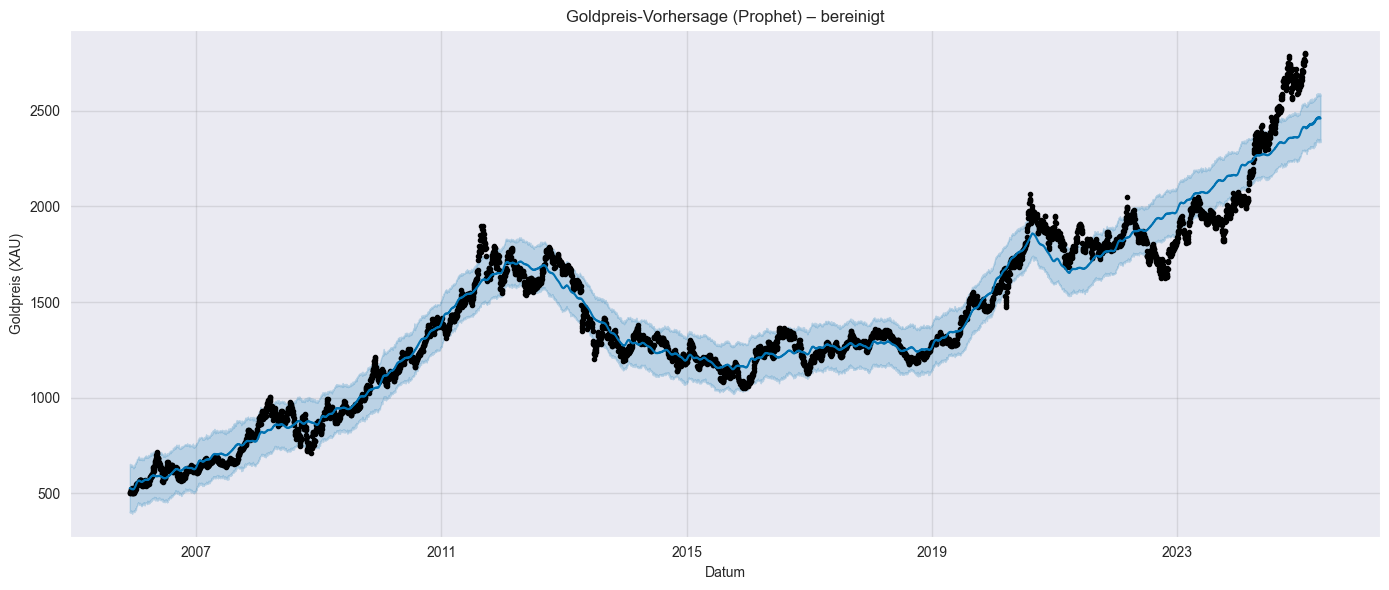

,ds,yhat,yhat_lower,yhat_upper
4918,2025-02-04,2411.620809,2291.892670,2534.027587
4919,2025-02-05,2411.459737,2294.508276,2524.623501
4920,2025-02-06,2412.111408,2293.711074,2526.772614
4921,2025-02-07,2412.918701,2288.794680,2528.616291
4922,2025-02-08,2407.312458,2287.712292,2526.521317
...,...,...,...,...
5003,2025-04-30,2463.196625,2351.909986,2579.583908
5004,2025-05-01,2463.915304,2341.842778,2581.988616
5005,2025-05-02,2464.726191,2351.154703,2589.205514
5006,2025-05-03,2459.056878,2335.058610,2577.023690


In [17]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# 📥 1. Daten laden
df = pd.read_csv("../dataset/output/xau_clean.csv", parse_dates=["date_xau"])

# 🧹 2. Spalte konvertieren – versuche es direkt in float (notfalls mit Fehlerbehandlung)
df["close_xau"] = (
    df["close_xau"]
    .astype(str)
    .str.replace(r"[^\d,.\-]", "", regex=True)     # nur gültige Zeichen behalten
    .str.replace(",", ".", regex=False)
)

# Fehlerhafte Werte als NaN behandeln
df["close_xau"] = pd.to_numeric(df["close_xau"], errors="coerce")

# ❗ 3. Ausreißer entfernen: unrealistisch hohe oder niedrige Werte filtern
df = df[(df["close_xau"] > 500) & (df["close_xau"] < 5000)]

# 📊 4. Prophet-kompatibles Format
xau_df = df[["date_xau", "close_xau"]].dropna().copy()
xau_df["date_xau"] = pd.to_datetime(xau_df["date_xau"]).dt.tz_localize(None)
xau_df.columns = ["ds", "y"]

# 📈 5. Modell trainieren
model = Prophet(daily_seasonality=True)
model.fit(xau_df)

# 🔮 6. Vorhersage für 30 Tage
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# 📊 7. Visualisierung
fig = model.plot(forecast)
fig.set_size_inches(14, 6)
plt.title("Goldpreis-Vorhersage (Prophet) – bereinigt")
plt.xlabel("Datum")
plt.ylabel("Goldpreis (XAU)")
plt.tight_layout()
plt.show()

# 🔍 8. Vorhersagewerte anzeigen
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(90)
